# Paper 1 revision: GGH lattice encryption over a realistic MU-MIMO-OFDM uplink

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DanielGrahamB/pqc-research/blob/paper1-ggh-revision/Paper1_GGH_Revision.ipynb)

**Goal.** Redo every simulation of the GLOBECOM 2026 workshop paper *"Lattice-Based Physical Layer Security for 6G under Realistic Multiuser MIMO Channels"* (#879, rejected), fix the simulation bugs found after submission, and add the experiments the reviewers asked for. This notebook uses **GGH only**. ML-KEM / FrodoKEM + LDPC are kept for the next paper.

**New framing.** A critical, quantitative evaluation of GGH physical-layer encryption: what it costs (true SNR, CSI accuracy, complexity) and why, with corrected analysis.

| Part | Content | Reviewer point |
|---|---|---|
| 1 | Keys and the distributions of R, U, B; where the error spreads (R⁻¹ vs U⁻¹) | R3 "comment on the distributions for R and U"; corrects Eq. (11) |
| 2 | AWGN analysis: closed-form required SNR, theory vs simulation | R1 novelty, R2 "BLER very high" |
| 3 | Security vs SNR trade-off (key mixing, σ, n, key-to-key spread) | R1 "trade-off between security and reliability" |
| 4 | Reproducing the submitted Fig. 4 and isolating each bug | (honesty: the old floors were artifacts) |
| 5 | Main result on the true SNR axis: UMi / UMa / RMa, one fixed key, unencrypted baseline | R1 "compare with an unencrypted system" |
| 6 | Perfect vs imperfect CSI (Sionna LS, Gaussian error model, required CSI accuracy) | R1 "perfect channel knowledge" |
| 7 | Receiver: ZF vs LMMSE | R1 "receiver configurations" |
| 8 | Block size and error containment (full-band vs sub-band tiles) | corrected error-propagation mechanism |
| 9 | Users, antennas and modulation | R1 "vary users, antennas, modulation" |
| 10 | Eavesdropper: BER, the Q-branch leak, σ | security check |
| 11 | Complexity, latency, goodput | R3 "no throughput or latency analysis" |
| 12 | Summary tables (CSV) and figures for the paper | |

**Run on Colab:** Runtime → Run all. The first cell installs Sionna and restarts the runtime once; then run all again. `QUICK = True` gives a smoke test in a few minutes; `QUICK = False` (default) reproduces the paper figures (CPU: about 20–30 min).

Figures are saved as PDF and PNG in `figures_paper1/`, and numbers in `results_paper1/`.

In [1]:
# Colab setup: install Sionna and fetch lattice.py / metrics.py from this branch
import os, sys
if 'google.colab' in sys.modules:
    try:
        import sionna.phy
    except ImportError:
        print("Installing Sionna and restarting the runtime. Please run all cells again.")
        os.system("pip install -q sionna")
        os.kill(os.getpid(), 9)
    if not os.path.exists("lattice.py"):
        os.system("git clone -q -b paper1-ggh-revision https://github.com/DanielGrahamB/pqc-research.git repo"
                  " && cp repo/lattice.py repo/metrics.py .")

In [2]:
QUICK = False            # True: short smoke test (fewer Monte Carlo iterations)
FIG_DIR, RES_DIR = "figures_paper1", "results_paper1"
os.makedirs(FIG_DIR, exist_ok=True); os.makedirs(RES_DIR, exist_ok=True)

MC = dict(batch=16, target_tile_err=50 if QUICK else 200, max_iter=8 if QUICK else 100)
TARGET_BLER = 1e-2       # operating point used for "required SNR" tables

In [3]:
%matplotlib inline
import time, math, random, json, csv
import numpy as np
import torch
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)

import sionna.phy
sionna.phy.config.seed = 20
sionna.phy.config.precision = "double"        # GGH needs double precision everywhere (Part 4, bug B1)

from sionna.phy import Block
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import (ResourceGrid, ResourceGridMapper, LSChannelEstimator,
                             LMMSEEqualizer, ZFEqualizer, RemoveNulledSubcarriers)
from sionna.phy.channel.tr38901 import AntennaArray, UMi, UMa, RMa
from sionna.phy.channel import gen_single_sector_topology as gen_topology, OFDMChannel
from sionna.phy.mapping import Mapper, Demapper, BinarySource
from sionna.phy.utils import ebnodb2no

from lattice import LatticeBasedEncryptor
from metrics import hadamard_ratio

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEV = sionna.phy.config.device
print("torch", torch.__version__, "| device", DEV)

# IEEE-style figures (one column = 3.5 in)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "legend.fontsize": 7.5, "lines.markersize": 4})
COL = {"umi": "tab:blue", "uma": "tab:green", "rma": "tab:orange"}
NAME = {"umi": "UMi", "uma": "UMa", "rma": "RMa"}

def savefig(fig, name):
    fig.tight_layout()
    for ext in ["pdf", "png"]:
        fig.savefig(f"{FIG_DIR}/{name}.{ext}", bbox_inches="tight")
    plt.show()

def save_json(obj, name):
    with open(f"{RES_DIR}/{name}.json", "w") as f:
        json.dump(obj, f, indent=1, default=float)

torch 2.14.1 | device cpu


## Core code

**`GGHKey`** is the base station's key pair for lattice dimension n. Every user encrypts to the BS public key B, and the BS decrypts with R. One key per n is shared by all users and all scenarios. (In the submitted paper each scenario created a new random key, so differences between UMi, UMa and RMa were partly key-to-key differences.)

- R = k·I + E, with E i.i.d. uniform on {−2,…,2} and k grown until the Hadamard ratio HR(R) ≥ 0.8.
- U = product of `rounds`·n random elementary row operations rᵢ ← rᵢ + c·rⱼ, c uniform on ±{1,…,`max_coeff`}, so det U = ±1.
- B = R·U (the best of up to 30 draws, aiming for HR(B) ≤ 10⁻³).
- Encryption: c = B·m + e, m = integer QAM levels (±1, ±3 for 16-QAM), e = σ(±1 ± j) with independent uniform signs.
- σ = `sigma_frac` · 1/(2ρ_R), where ρ_R is the maximum L1 row norm of R⁻¹ (default `sigma_frac` = 0.9, as in the submitted paper).
- Bob: m̂ = U⁻¹·⌈R⁻¹ĉ⌋. U⁻¹ = B⁻¹R is computed once, rounded to integers and checked (W·U = I exactly).
- Eve: m̂ = ⌈B⁻¹ĉ⌋ (round-off with the public basis).

**`GGHUplink`** is the 3GPP TR 38.901 MU-MIMO-OFDM uplink (Sionna): K single-antenna users, M BS antennas, 128 subcarriers at 30 kHz, 14 OFDM symbols, pilots on symbols 2 and 11 (Kronecker), 3.5 GHz. Each lattice block is a **tile** of w subcarriers × T data OFDM symbols (n = w·T). The full-band tile 128×4 (n = 512) is the submitted paper's setup.

**True SNR axis.** With `true_snr=True` the ciphertext is divided by √P (P = average ciphertext power, a fixed public constant per key), so the transmit power is 1 and Eb/N0 is the physical one. With `true_snr=False` the raw ciphertext is sent, which is the submitted paper's (mislabelled) axis.

In [4]:
QAM_SCALE = {2: math.sqrt(2.0), 4: math.sqrt(10.0), 6: math.sqrt(42.0)}   # unit power -> odd integers

def cround(z):
    return torch.round(z.real) + 1j * torch.round(z.imag)

class GGHKey:
    def __init__(self, n, seed=0, sigma_frac=0.9, rounds=5, max_coeff=3):
        torch.manual_seed(seed)
        eng = LatticeBasedEncryptor(n=n, rounds=rounds, max_coeff=max_coeff, verbose=False, complex_error=True)
        self.n, self.seed, self.rounds, self.max_coeff, self.sigma_frac = n, seed, rounds, max_coeff, sigma_frac
        self.info = dict(eng.info)
        self.sigma = sigma_frac * eng.info["sigma_max_correct"]
        self.R = eng.R.clone().to(torch.float64)
        self.B = eng.B.clone().to(torch.float64)
        self.R_inv = torch.linalg.inv(self.R)
        self.B_inv = torch.linalg.pinv(self.B)
        self.U = torch.round(self.R_inv @ self.B)
        self.W = torch.round(self.B_inv @ self.R)                    # U^{-1}, integer
        self.exact = bool(torch.equal(self.W @ self.U, torch.eye(n)))
        self.k_diag = float(self.R[0, 0])
        self._P = {}

    def to(self, dev):
        for a in ["R", "B", "R_inv", "B_inv", "U", "W"]:
            setattr(self, a, getattr(self, a).to(dev))
        return self

    def error(self, shape, device, complex_error=True):
        sgn = lambda: 2.0 * torch.randint(0, 2, shape, device=device, dtype=torch.float64) - 1.0
        return self.sigma * (sgn() + 1j * sgn()) if complex_error else self.sigma * sgn() + 0j

    def encrypt(self, m, complex_error=True, e_scale=1.0):
        return m @ self.B.T.to(m.dtype) + e_scale * self.error(m.shape, m.device, complex_error)

    def babai(self, c):                     # z = round(R^{-1} c), z = U m when decryption succeeds
        return cround(c @ self.R_inv.T.to(c.dtype))

    def decrypt(self, c):
        return self.babai(c) @ self.W.T.to(c.dtype)

    def eve_roundoff(self, c):
        return cround(c @ self.B_inv.T.to(c.dtype))

    def cipher_power(self, bits):
        # Average |c|^2 for unit-power QAM input (measured once, fixed public constant)
        if bits not in self._P:
            g = torch.Generator().manual_seed(1)
            L = int(2 ** (bits // 2)); lv = torch.arange(-(L - 1), L, 2, dtype=torch.float64)
            m = (lv[torch.randint(0, L, (256, self.n), generator=g)]
                 + 1j * lv[torch.randint(0, L, (256, self.n), generator=g)]).to(self.B.device)
            self._P[bits] = float(torch.mean(torch.abs(self.encrypt(m) / QAM_SCALE[bits]) ** 2))
        return self._P[bits]

_KEYS = {}
def get_key(n, seed=0, **kw):
    k = (n, seed, tuple(sorted(kw.items())))
    if k not in _KEYS:
        _KEYS[k] = GGHKey(n, seed=seed, **kw).to(DEV)
    return _KEYS[k]

In [5]:
from contextlib import contextmanager
@contextmanager
def sionna_precision(p):
    # Temporarily switch Sionna's global precision (used to reproduce the float32 channel bug)
    old = sionna.phy.config.precision
    sionna.phy.config.precision = p
    try:
        yield
    finally:
        sionna.phy.config.precision = old


def build_tile_perm(rg, band_width, band_time):
    # Reorders the data REs (Sionna order) tile by tile: w subcarriers x T data OFDM symbols.
    mask = rg.pilot_pattern.mask
    mask = (mask.cpu().numpy() if hasattr(mask, "cpu") else np.asarray(mask))[0, 0]
    coords = np.argwhere(mask == 0)
    assert len(coords) == rg.num_data_symbols
    sym_ids = np.unique(coords[:, 0]); t_rank = np.searchsorted(sym_ids, coords[:, 0]); sc = coords[:, 1]
    n_sym, n_sc = len(sym_ids), int(sc.max()) + 1
    assert n_sc % band_width == 0 and n_sym % band_time == 0, "tile must divide the data grid"
    tile_id = (t_rank // band_time) * (n_sc // band_width) + (sc // band_width)
    perm = np.argsort(tile_id, kind="stable")
    return perm, np.argsort(perm), band_width * band_time, len(perm) // (band_width * band_time)


class GGHUplink(Block):
    # scenario: "umi" | "uma" | "rma";  key: GGHKey or None (unencrypted baseline)
    # tile: (w, T);  K users, M BS antennas;  bits per QAM symbol: 2 | 4 | 6
    # csi: "perfect" | "ls-nn" | "ls-lin" | "gauss" (h_hat = h + CN(0, nmse); nmse = N0 if csi_nmse_db is None)
    # equalizer: "zf" | "lmmse";  true_snr: unit transmit power (True) or raw ciphertext (False)
    # role: "bob" | "eve";  complex_error: False = real-only error vector (Q-branch leak)
    # chan_precision / sqrt10_bug: reproduce the submitted pipeline (Part 4)
    def __init__(self, scenario="umi", key=None, tile=(128, 4), K=4, M=8, bits=4, csi="perfect",
                 csi_nmse_db=None, equalizer="zf", true_snr=True, role="bob", complex_error=True,
                 chan_precision="double", sqrt10_bug=False):
        super().__init__()
        self.scenario, self.key, self.K, self.M, self.bits = scenario, key, K, M, bits
        self.csi, self.csi_nmse_db, self.role, self.complex_error = csi, csi_nmse_db, role, complex_error
        self.chan_precision, self.e_scale = chan_precision, (QAM_SCALE[bits] if sqrt10_bug else 1.0)
        fc = 3.5e9
        self.rg = ResourceGrid(num_ofdm_symbols=14, fft_size=128, subcarrier_spacing=30e3,
                               num_tx=K, num_streams_per_tx=1, cyclic_prefix_length=20,
                               pilot_pattern="kronecker", pilot_ofdm_symbol_indices=[2, 11])
        self.sm = StreamManagement(np.ones([1, K]), 1)
        with sionna_precision(chan_precision):          # channel blocks in their own precision
            ut = AntennaArray(num_rows=1, num_cols=1, polarization="single", polarization_type="V",
                              antenna_pattern="omni", carrier_frequency=fc)
            bs = AntennaArray(num_rows=1, num_cols=M // 2, polarization="dual", polarization_type="cross",
                              antenna_pattern="38.901", carrier_frequency=fc)
            common = dict(carrier_frequency=fc, ut_array=ut, bs_array=bs, direction="uplink",
                          enable_pathloss=False, enable_shadow_fading=False)
            self.chan_model = {"umi": lambda: UMi(o2i_model="low", **common),
                               "uma": lambda: UMa(o2i_model="low", **common),
                               "rma": lambda: RMa(**common)}[scenario]()
            self.channel = OFDMChannel(self.chan_model, self.rg, normalize_channel=True, return_channel=True)
        self.rg_mapper = ResourceGridMapper(self.rg)
        self.remove_nulled = RemoveNulledSubcarriers(self.rg)
        self.ls = LSChannelEstimator(self.rg, interpolation_type=csi.split("-")[1]) if csi.startswith("ls") else None
        self.eq = (ZFEqualizer if equalizer == "zf" else LMMSEEqualizer)(self.rg, self.sm)
        self.source, self.mapper = BinarySource(), Mapper("qam", bits)
        self.demapper = Demapper("app", "qam", bits, hard_out=True)
        self.k = int(self.rg.num_data_symbols * bits)                    # bits per user per slot
        perm, inv, self.n, self.num_tiles = build_tile_perm(self.rg, *tile)
        self.perm, self.inv = torch.tensor(perm, device=DEV), torch.tensor(inv, device=DEV)
        if key is not None:
            assert key.n == self.n, f"key n={key.n} but tile gives n={self.n}"
        self.qs = QAM_SCALE[bits]
        self.P = key.cipher_power(bits) if (key is not None and true_snr) else 1.0
        self.amp = math.sqrt(self.P)

    def new_topology(self, batch):
        with sionna_precision(self.chan_precision):
            self.chan_model.set_topology(*gen_topology(batch, self.K, self.scenario,
                                                       min_ut_velocity=0.0, max_ut_velocity=0.0))

    def tiles(self, x):
        x = x[..., self.perm]
        return x.reshape(*x.shape[:-1], self.num_tiles, self.n)

    def untiles(self, x):
        return x.reshape(*x.shape[:-2], self.num_tiles * self.n)[..., self.inv]

    def call(self, batch, ebno_db):
        self.new_topology(batch)
        no = ebnodb2no(ebno_db, self.bits, 1.0, self.rg)
        b = self.source([batch, self.K, 1, self.k])
        x = self.mapper(b)
        m = cround(self.tiles(x) * self.qs)                              # integer QAM levels
        if self.key is not None:
            c = self.key.encrypt(m, self.complex_error, self.e_scale)
            tx = self.untiles(c) / self.qs / self.amp
        else:
            tx = x
        x_rg = self.rg_mapper(tx)
        if self.chan_precision == "single":
            with sionna_precision("single"):
                y, h = self.channel(x_rg.to(torch.complex64), torch.as_tensor(no, dtype=torch.float32))
            y, h = y.to(torch.complex128), h.to(torch.complex128)
        else:
            y, h = self.channel(x_rg, no)
        if self.ls is not None:
            h_hat, err_var = self.ls(y, no)
        else:
            h_hat, err_var = self.remove_nulled(h), torch.zeros((), device=y.device)
            if self.csi == "gauss":
                nmse = float(no) if self.csi_nmse_db is None else 10 ** (self.csi_nmse_db / 10)
                h_hat = h_hat + math.sqrt(nmse / 2) * torch.complex(torch.randn_like(h_hat.real),
                                                                    torch.randn_like(h_hat.real))
                err_var = torch.full((), nmse, device=y.device)
        x_hat, _ = self.eq(y, h_hat, err_var, no)
        z_err = None
        if self.key is not None:
            c_hat = self.tiles(x_hat) * self.qs * self.amp
            if self.role == "bob":
                z_hat = self.key.babai(c_hat)
                z_err = (torch.abs(z_hat - m @ self.key.U.T.to(m.dtype)) > 0.5).sum(-1)
                m_hat = z_hat @ self.key.W.T.to(c_hat.dtype)
            else:
                m_hat = self.key.eve_roundoff(c_hat)
            x_dec = self.untiles(m_hat) / self.qs
        else:
            x_dec = x_hat
        b_hat = self.demapper(x_dec, torch.full((), 1e-3, device=x_dec.device))
        sym_hat = self.tiles(self.mapper(b_hat.to(b.dtype)) * self.qs)
        sym_err = (torch.abs(sym_hat - m) > 0.5).sum(-1)                 # wrong symbols per tile
        return b, b_hat, sym_err, z_err

In [6]:
def simulate(model, ebno_dbs, batch=None, target_tile_err=None, max_iter=None, label="", verbose=True,
             stop_at_zero=True):
    # Monte Carlo. BLER = lattice-block (tile) error rate. Stops after the first error-free point.
    batch = batch or MC["batch"]; target_tile_err = target_tile_err or MC["target_tile_err"]
    max_iter = max_iter or MC["max_iter"]
    out = {k: [] for k in ["ebno_db", "ber", "bler", "tiles", "tile_err", "sym_fail", "z_fail"]}
    t0 = time.time()
    for e in ebno_dbs:
        nb = be = te = nt = 0; sf, zf = [], []
        for _ in range(max_iter):
            with torch.no_grad():
                b, b_hat, se, ze = model(batch, float(e))
            be += int((b != b_hat).sum()); nb += b.numel()
            te += int((se > 0).sum()); nt += se.numel()
            sf += se[se > 0].tolist()
            if ze is not None:
                zf += ze[se > 0].tolist()
            if te >= target_tile_err:
                break
        for k_, v in zip(["ebno_db", "ber", "bler", "tiles", "tile_err", "sym_fail", "z_fail"],
                         [float(e), be / nb, te / nt, nt, te, sf, zf]):
            out[k_].append(v)
        if verbose:
            print(f"  {label:34s} {e:7.1f} dB | BER {be/nb:9.3e} | BLER {te/nt:9.3e} ({te}/{nt}) | {time.time()-t0:6.1f}s")
        if stop_at_zero and te == 0:
            break
    return out


def snr_at(res, target=None, key="bler"):
    # Eb/N0 where the curve crosses `target` (log-linear interpolation); nan if never reached
    target = target or TARGET_BLER
    x, y = np.array(res["ebno_db"]), np.array(res[key])
    for i in range(1, len(x)):
        if y[i - 1] > target >= y[i]:
            if y[i] <= 0:
                return float(x[i - 1] + (x[i] - x[i - 1]) * 0.5) if y[i - 1] < 1 else float(x[i])
            f = (np.log10(y[i - 1]) - np.log10(target)) / (np.log10(y[i - 1]) - np.log10(y[i]))
            return float(x[i - 1] + f * (x[i] - x[i - 1]))
    return float("nan")


def plot_curve(ax, res, key="bler", **kw):
    x, y = np.array(res["ebno_db"]), np.array(res[key], dtype=float)
    y = np.where(y > 0, y, np.nan)
    ax.semilogy(x, y, **kw)

GGH_GRID = np.arange(80.0, 150.1, 2.5)
PLAIN_GRID = np.arange(0.0, 40.1, 2.5)

## Part 1. Keys, distributions, and where the error spreads

The main key is n = 512 (full-band tile 128×4). The table also lists the keys used for sub-band tiles. `P_c` is the average ciphertext power for unit-power 16-QAM, i.e. the **ciphertext expansion**: how much stronger c = B·m + e is than m.

In [7]:
KEY_NS = [192, 384, 512]
rows = []
print(f"{'n':>4s}{'k':>5s}{'HR(R)':>8s}{'HR(B)':>10s}{'rho_R':>8s}{'sigma':>8s}{'sigma window':>22s}"
      f"{'max|B|':>10s}{'max|U^-1|':>11s}{'P_c (dB)':>10s}{'W exact':>9s}")
for n in KEY_NS:
    kk = get_key(n)
    i = kk.info
    P_db = 10 * np.log10(kk.cipher_power(4))
    rows.append(dict(n=n, k=kk.k_diag, hr_R=i["hr_R"], hr_B=i["hr_B"], rho_R=i["rho_R"], sigma=kk.sigma,
                     sigma_lo=i["sigma_min_secure"], sigma_hi=i["sigma_max_correct"],
                     max_B=float(kk.B.abs().max()), max_W=float(kk.W.abs().max()), P_c_db=P_db))
    print(f"{n:4d}{kk.k_diag:5.0f}{i['hr_R']:8.3f}{i['hr_B']:10.2e}{i['rho_R']:8.3f}{kk.sigma:8.3f}"
          f"   [{i['sigma_min_secure']:.1e}, {i['sigma_max_correct']:.3f}]{float(kk.B.abs().max()):10.2e}"
          f"{float(kk.W.abs().max()):11.2e}{P_db:10.1f}{str(kk.exact):>9s}")
save_json(rows, "keys")

   n    k   HR(R)     HR(B)   rho_R   sigma          sigma window    max|B|  max|U^-1|  P_c (dB)  W exact
 192   30   0.855  4.28e-04   0.379   1.186   [2.9e-05, 1.318]  2.98e+06   4.98e+04     115.2     True


/var/folders/k6/swqzx6ss7xx79pzl4fbtgg3h0000gn/T/ipykernel_73678/4024507830.py:13: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/Copy.cpp:308.)
  self.R = eng.R.clone().to(torch.float64)


 384   47   0.865  5.21e-04   0.323   1.395   [2.3e-05, 1.550]  3.71e+06   6.93e+04     113.5     True


 512   46   0.832  5.13e-04   0.433   1.040   [8.6e-06, 1.155]  3.16e+06   1.05e+05     113.8     True


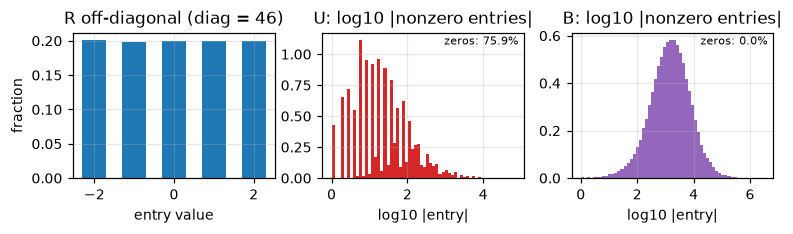

In [8]:
key = get_key(512)
R, U, B, Rinv, W = [t.cpu().numpy() for t in [key.R, key.U, key.B, key.R_inv, key.W]]
off = ~np.eye(key.n, dtype=bool)

fig, ax = plt.subplots(1, 3, figsize=(7.2, 2.2))
vals, cnt = np.unique(R[off], return_counts=True)
ax[0].bar(vals, cnt / cnt.sum(), width=0.6, color="tab:blue")
ax[0].set_title(f"R off-diagonal (diag = {key.k_diag:.0f})"); ax[0].set_xlabel("entry value"); ax[0].set_ylabel("fraction")
for a_, M_, name in [(ax[1], U, "U"), (ax[2], B, "B")]:
    v = np.abs(M_[M_ != 0]).ravel()
    a_.hist(np.log10(v), bins=60, color="tab:red" if name == "U" else "tab:purple", density=True)
    a_.set_title(f"{name}: log10 |nonzero entries|"); a_.set_xlabel("log10 |entry|")
    a_.text(0.97, 0.92, f"zeros: {np.mean(M_ == 0)*100:.1f}%", transform=a_.transAxes, ha="right", fontsize=7)
savefig(fig, "fig_key_distributions")

**Where does one bad subcarrier spread?** The submitted Eq. (11) said R⁻¹ mixes the residuals of all N subcarriers. The plot below shows that R⁻¹ is close to diagonal (R = k·I + small noise), so the rounding step ⌈R⁻¹ĉ⌋ sees **mostly local** errors. The spreading happens **after** rounding, through the dense integer matrix U⁻¹: one wrong integer zᵢ adds the whole column i of U⁻¹ to the message. Part 8 measures this directly (wrong integers before U⁻¹ vs wrong symbols after it).

share of row L1 mass on the diagonal: R^-1 = 0.057, U^-1 = 1.90e-03
average nonzeros per row of U^-1: 122 of 512


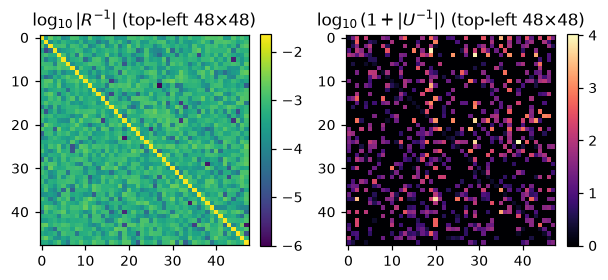

In [9]:
def diag_share(M_):
    a = np.abs(M_); return float(np.mean(np.diag(a) / a.sum(1)))
print(f"share of row L1 mass on the diagonal: R^-1 = {diag_share(Rinv):.3f}, U^-1 = {diag_share(W):.2e}")
print(f"average nonzeros per row of U^-1: {np.mean((W != 0).sum(1)):.0f} of {key.n}")

fig, ax = plt.subplots(1, 2, figsize=(5.6, 2.5))
s = 48
im0 = ax[0].imshow(np.log10(np.abs(Rinv[:s, :s]) + 1e-12), cmap="viridis", vmin=-6)
ax[0].set_title(r"$\log_{10}|R^{-1}|$ (top-left 48×48)"); plt.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(np.log10(np.abs(W[:s, :s]) + 1), cmap="magma")
ax[1].set_title(r"$\log_{10}(1+|U^{-1}|)$ (top-left 48×48)"); plt.colorbar(im1, ax=ax[1], fraction=0.046)
for a_ in ax: a_.grid(False)
savefig(fig, "fig_mixing_Rinv_vs_Uinv")

## Part 2. AWGN analysis: why GGH needs a very high SNR

With unit transmit power, the receiver scales ĉ back by √P_int (P_int = E|c|² in the integer domain). Before rounding, real coordinate j of R⁻¹ĉ is

  zⱼ + aⱼ + wⱼ,  aⱼ = [R⁻¹e]ⱼ (bounded by σρ_R),  wⱼ ~ N(0, sⱼ²),  sⱼ² = (N₀ P_int / 2)·‖rⱼ‖²,

with rⱼ row j of R⁻¹. Decryption is correct iff |aⱼ + wⱼ| < ½ for all 2n real coordinates, so

  **BLER = 1 − E_e ∏ⱼ [Φ((½ − aⱼ)/sⱼ) − Φ((−½ − aⱼ)/sⱼ)].**

Requiring every coordinate to hold with probability 1 − p/(2n) gives a closed form for the required Es/N0:

  **(Es/N0)_req ≈ P_int · ‖r‖² · g² / (2δ²),  g = Q⁻¹(p / 4n),  δ = margin ∈ [½ − σρ_R, ½].**

In dB this splits into two terms: the **ciphertext expansion** γ = P_int / E|m|² (huge, set by the public basis), and a **lattice-decoding term** E|m|²‖r‖²g²/(2δ²) (moderate, set by R and σ). The first term is what the submitted paper's axis hid.

In [10]:
from torch.special import ndtr

def theory_bler_awgn(kk, esno_db, bits=4, n_e=200):
    # Exact BLER of Babai round-off in AWGN (unit transmit power), averaged over n_e error vectors
    P_int = kk.cipher_power(bits) * QAM_SCALE[bits] ** 2
    Rinv = kk.R_inv.cpu(); rn2 = (Rinv ** 2).sum(1)
    g = torch.Generator().manual_seed(3)
    e = kk.sigma * (2.0 * torch.randint(0, 2, (n_e, 2 * kk.n), generator=g, dtype=torch.float64) - 1)
    a = torch.cat([e[:, :kk.n] @ Rinv.T, e[:, kk.n:] @ Rinv.T], 1)          # [n_e, 2n]
    s_all = torch.cat([rn2, rn2])
    out = []
    for es in np.atleast_1d(esno_db):
        N0 = 10 ** (-es / 10)
        s = torch.sqrt(N0 * P_int / 2 * s_all)
        p_ok = (ndtr((0.5 - a) / s) - ndtr((-0.5 - a) / s)).clamp_min(1e-300)
        out.append(float(1 - torch.exp(torch.log(p_ok).sum(1)).mean()))
    return np.array(out)

def closed_form_esno(kk, p=None, bits=4, margin="typical"):
    # Closed-form required Es/N0 (dB), split into ciphertext expansion + lattice decoding term
    p = p or TARGET_BLER
    from statistics import NormalDist
    P_int = kk.cipher_power(bits) * QAM_SCALE[bits] ** 2
    Em2 = 2 * (2 ** bits - 1) / 3                                   # E|m|^2 of integer QAM
    r2 = float((kk.R_inv ** 2).sum(1).max())
    g = NormalDist().inv_cdf(1 - p / (4 * kk.n))
    rho_R = kk.info["rho_R"]
    if margin == "worst":
        d = 0.5 - kk.sigma * rho_R
    elif margin == "none":
        d = 0.5
    else:   # typical: |a_j| ~ sigma * ||r_j||_2 * 3
        d = 0.5 - 3 * kk.sigma * math.sqrt(r2)
    expansion = 10 * np.log10(P_int / Em2)
    lattice_term = 10 * np.log10(Em2 * r2 * g ** 2 / (2 * d ** 2))
    return expansion + lattice_term, expansion, lattice_term

def mc_bler_awgn(kk, esno_db, bits=4, blocks=4000):
    # Monte Carlo AWGN: unit-power ciphertext + complex Gaussian noise, Babai with R
    L = int(2 ** (bits // 2)); lv = torch.arange(-(L - 1), L, 2, dtype=torch.float64, device=DEV)
    P_int = kk.cipher_power(bits) * QAM_SCALE[bits] ** 2
    out = []
    for es in np.atleast_1d(esno_db):
        N0 = 10 ** (-es / 10); err = tot = 0
        for _ in range(max(1, blocks // 500)):
            m = lv[torch.randint(0, L, (500, kk.n), device=DEV)] + 1j * lv[torch.randint(0, L, (500, kk.n), device=DEV)]
            c = kk.encrypt(m)
            noise = math.sqrt(N0 * P_int / 2) * torch.complex(torch.randn_like(c.real), torch.randn_like(c.real))
            m_hat = kk.decrypt(c + noise)
            err += int((torch.abs(m_hat - m) > 0.5).any(-1).sum()); tot += 500
        out.append(err / tot)
    return np.array(out)

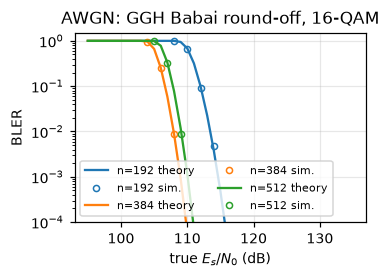

Required true Es/N0 for BLER = 0.01 (AWGN, 16-QAM)
   n   exact  closed form    [δ=1/2 .. worst δ]  = expansion  + lattice
 192   113.5        117.7   [114.1 .. 134.1]        115.2        2.4
 384   107.9        110.9   [108.5 .. 128.5]        113.5       -2.5
 512   109.1        111.6   [109.7 .. 129.7]        113.8       -2.3


Unencrypted 16-QAM, block of 512 symbols, AWGN: 19.8 dB  -> GGH (n=512) penalty 89.3 dB


In [11]:
ES_GRID = np.arange(95.0, 135.1, 1.0)
fig, ax = plt.subplots(figsize=(3.5, 2.6))
awgn_rows = []
for i, n in enumerate(KEY_NS):
    kk = get_key(n)
    th = theory_bler_awgn(kk, ES_GRID)
    mc_grid = ES_GRID[(th > 3e-4) & (th < 0.999)][::2]
    mc = mc_bler_awgn(kk, mc_grid, blocks=1000 if QUICK else 4000)
    ax.semilogy(ES_GRID, th, "-", color=f"C{i}", label=f"n={n} theory")
    ax.semilogy(mc_grid, np.where(mc > 0, mc, np.nan), "o", color=f"C{i}", mfc="none", label=f"n={n} sim.")
    tot, exp_, lat = closed_form_esno(kk)
    worst = closed_form_esno(kk, margin="worst")[0]; best = closed_form_esno(kk, margin="none")[0]
    exact = float(np.interp(-np.log10(TARGET_BLER), -np.log10(np.maximum(th, 1e-12)), ES_GRID))
    awgn_rows.append(dict(n=n, esno_exact=exact, esno_closed=tot, esno_closed_best=best, esno_closed_worst=worst,
                          expansion_db=exp_, lattice_term_db=lat))
ax.set_xlabel("true $E_s/N_0$ (dB)"); ax.set_ylabel("BLER"); ax.set_ylim(1e-4, 1.5); ax.legend(ncol=2)
ax.set_title("AWGN: GGH Babai round-off, 16-QAM")
savefig(fig, "fig_awgn_theory_vs_sim")

print(f"Required true Es/N0 for BLER = {TARGET_BLER:g} (AWGN, 16-QAM)")
print(f"{'n':>4s}{'exact':>8s}{'closed form':>13s}{'[δ=1/2 .. worst δ]':>22s}{'= expansion':>13s}{'+ lattice':>11s}")
for r in awgn_rows:
    print(f"{r['n']:4d}{r['esno_exact']:8.1f}{r['esno_closed']:13.1f}   [{r['esno_closed_best']:5.1f} .. {r['esno_closed_worst']:5.1f}]"
          f"{r['expansion_db']:13.1f}{r['lattice_term_db']:11.1f}")
def plain_bler_awgn(esno_db, n=512):
    # Unencrypted 16-QAM block of n symbols in AWGN (exact symbol error rate)
    from scipy.stats import norm
    q = norm.sf(np.sqrt(10 ** (np.asarray(esno_db) / 10) / 5))
    ser = 1 - (1 - 1.5 * q) ** 2
    return 1 - (1 - ser) ** n
g_ = np.arange(0, 40, 0.01)
plain_req = float(g_[np.argmax(plain_bler_awgn(g_) <= TARGET_BLER)])
print(f"Unencrypted 16-QAM, block of 512 symbols, AWGN: {plain_req:.1f} dB  -> GGH (n=512) penalty "
      f"{awgn_rows[-1]['esno_exact'] - plain_req:.1f} dB")
save_json(awgn_rows, "awgn_required_snr")

## Part 3. The security vs SNR trade-off

GGH has **no modulus**, so a "worse" (more mixed, more secure) public basis gives a **larger** ciphertext and a higher required SNR. HR(B) (Hadamard ratio, lower = harder for round-off/nearest-plane attacks) is used as the security proxy, as in [15]. It is a heuristic, not a security proof.

Four sweeps (analytic AWGN BLER, exact formula of Part 2):
1. key mixing: `rounds` × `max_coeff` at n = 512,
2. σ placement inside the window (`sigma_frac`),
3. lattice dimension n,
4. key-to-key spread: 20 random keys at n = 512.

In [12]:
def req_esno(kk, lo=0, hi=200):
    # Bisection on the exact AWGN BLER for TARGET_BLER
    for _ in range(30):
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if theory_bler_awgn(kk, [mid], n_e=50)[0] > TARGET_BLER else (lo, mid)
    return (lo + hi) / 2

trade = []
for rounds in ([1, 3, 5] if QUICK else [1, 2, 3, 4, 5]):
    for mc_ in [1, 2, 3]:
        kk = GGHKey(512, seed=0, rounds=rounds, max_coeff=mc_).to(DEV)
        trade.append(dict(rounds=rounds, max_coeff=mc_, hr_B=kk.info["hr_B"],
                          P_c_db=10 * np.log10(kk.cipher_power(4)), esno=req_esno(kk)))
        print(f"rounds={rounds} max_coeff={mc_}: HR(B)={trade[-1]['hr_B']:.2e}  P_c={trade[-1]['P_c_db']:6.1f} dB"
              f"  required Es/N0={trade[-1]['esno']:6.1f} dB")

sig = []
for sf in [0.1, 0.3, 0.5, 0.7, 0.9]:
    kk = GGHKey(512, seed=0, sigma_frac=sf).to(DEV)
    sig.append(dict(sigma_frac=sf, sigma=kk.sigma, esno=req_esno(kk)))
dims = []
for n in ([128, 256, 512] if QUICK else [64, 128, 192, 256, 384, 512, 768]):
    kk = GGHKey(n, seed=0).to(DEV)
    dims.append(dict(n=n, hr_B=kk.info["hr_B"], P_c_db=10 * np.log10(kk.cipher_power(4)), esno=req_esno(kk)))
spread = []
for s_ in range(5 if QUICK else 20):
    kk = GGHKey(512, seed=100 + s_).to(DEV)
    spread.append(dict(seed=100 + s_, hr_B=kk.info["hr_B"], P_c_db=10 * np.log10(kk.cipher_power(4)), esno=req_esno(kk)))
save_json(dict(mixing=trade, sigma=sig, dimension=dims, key_spread=spread), "tradeoff")

rounds=1 max_coeff=1: HR(B)=5.09e-01  P_c=  39.7 dB  required Es/N0=  35.0 dB


rounds=1 max_coeff=2: HR(B)=3.24e-01  P_c=  46.6 dB  required Es/N0=  41.9 dB


rounds=1 max_coeff=3: HR(B)=2.25e-01  P_c=  54.0 dB  required Es/N0=  49.3 dB


rounds=2 max_coeff=1: HR(B)=3.09e-01  P_c=  44.1 dB  required Es/N0=  39.4 dB


rounds=2 max_coeff=2: HR(B)=1.19e-01  P_c=  57.7 dB  required Es/N0=  53.0 dB


...

rounds=4 max_coeff=2: HR(B)=1.22e-02  P_c=  80.8 dB  required Es/N0=  76.1 dB


rounds=4 max_coeff=3: HR(B)=1.84e-03  P_c= 109.2 dB  required Es/N0= 104.5 dB


rounds=5 max_coeff=1: HR(B)=6.93e-02  P_c=  57.1 dB  required Es/N0=  52.4 dB


rounds=5 max_coeff=2: HR(B)=4.14e-03  P_c=  87.3 dB  required Es/N0=  82.5 dB


rounds=5 max_coeff=3: HR(B)=5.13e-04  P_c= 113.8 dB  required Es/N0= 109.1 dB


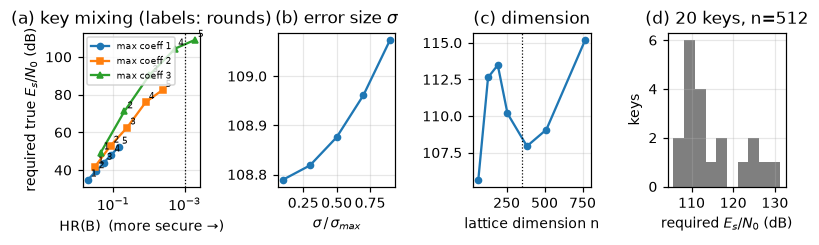

key-to-key spread at n=512: 105.7 .. 131.3 dB (mean 114.6)


In [13]:
fig, ax = plt.subplots(1, 4, figsize=(7.2, 2.3))
for mc_, mk in zip([1, 2, 3], ["o", "s", "^"]):
    t = [r for r in trade if r["max_coeff"] == mc_]
    ax[0].semilogx([r["hr_B"] for r in t], [r["esno"] for r in t], mk + "-", label=f"max coeff {mc_}")
    for r in t: ax[0].annotate(str(r["rounds"]), (r["hr_B"], r["esno"]), fontsize=6, xytext=(2, 2), textcoords="offset points")
ax[0].axvline(1e-3, color="k", ls=":", lw=0.8); ax[0].invert_xaxis()
ax[0].set_xlabel("HR(B)  (more secure →)"); ax[0].set_ylabel("required true $E_s/N_0$ (dB)"); ax[0].legend(fontsize=6)
ax[0].set_title("(a) key mixing (labels: rounds)")
ax[1].plot([r["sigma_frac"] for r in sig], [r["esno"] for r in sig], "o-")
ax[1].set_xlabel(r"$\sigma\,/\,\sigma_{max}$"); ax[1].set_title(r"(b) error size $\sigma$")
ax[2].plot([r["n"] for r in dims], [r["esno"] for r in dims], "o-")
ax[2].axvline(350, color="k", ls=":", lw=0.8); ax[2].set_xlabel("lattice dimension n"); ax[2].set_title("(c) dimension")
ax[3].hist([r["esno"] for r in spread], bins=10, color="tab:gray")
ax[3].set_xlabel("required $E_s/N_0$ (dB)"); ax[3].set_ylabel("keys"); ax[3].set_title("(d) 20 keys, n=512")
savefig(fig, "fig_security_vs_snr_tradeoff")
e_ = [r["esno"] for r in spread]
print(f"key-to-key spread at n=512: {min(e_):.1f} .. {max(e_):.1f} dB (mean {np.mean(e_):.1f})")

## Part 4. Reproducing the submitted Fig. 4, then removing each bug

The submitted curves (BLER = 1 until about 40 dB, then floors of 10⁻²–10⁻¹) came from four simulation problems found after submission:

- **B1** the 3GPP channel ran in single precision (float32 error on a ~10⁶–10⁷ ciphertext is far larger than the Babai margin);
- **B2** normalised QAM symbols were encrypted and the receiver multiplied by √10, so the error vector was √10× too large (σ beyond the correctness bound);
- **B3** Sionna's LMMSE equaliser assumes unit-power symbols, but the raw ciphertext is about 10¹¹ times stronger;
- **B4** the x-axis did not count the ciphertext power (labelled vs true SNR).

Each step below removes one problem (UMi, n = 512, perfect CSI). The float32 floor depends on the key (B1 does not hurt every key): we use key seed 7, for which the floor is visible, and run the submitted chain up to 120 dB to show that the floor does not move with SNR. The exact floor heights of the submitted Fig. 4 are not reproduced: they also depended on the random key drawn per scenario and on counting BLER per 3-block codeword. The last panel is the corrected result on the true axis.

  submitted chain (B1+B2+B3, labelle   -20.0 dB | BER 5.001e-01 | BLER 1.000e+00 (384/384) |    0.3s


  submitted chain (B1+B2+B3, labelle   -15.0 dB | BER 4.995e-01 | BLER 1.000e+00 (384/384) |    0.5s


  submitted chain (B1+B2+B3, labelle   -10.0 dB | BER 5.007e-01 | BLER 1.000e+00 (384/384) |    0.8s


  submitted chain (B1+B2+B3, labelle    -5.0 dB | BER 4.999e-01 | BLER 1.000e+00 (384/384) |    1.0s


  submitted chain (B1+B2+B3, labelle     0.0 dB | BER 4.996e-01 | BLER 1.000e+00 (384/384) |    1.3s


...

  true axis                            115.0 dB | BER 1.937e-03 | BLER 1.555e-02 (200/12864) |   11.0s


  true axis                            117.5 dB | BER 3.782e-04 | BLER 3.177e-03 (61/19200) |   21.1s


  true axis                            120.0 dB | BER 2.457e-05 | BLER 3.646e-04 (7/19200) |   31.0s


  true axis                            122.5 dB | BER 8.013e-05 | BLER 4.687e-04 (9/19200) |   41.0s


  true axis                            125.0 dB | BER 0.000e+00 | BLER 0.000e+00 (0/19200) |   51.6s

submitted-chain BLER at labelled 80 / 100 / 120 dB: ['2.3e-03', '1.3e-03', '2.1e-03']


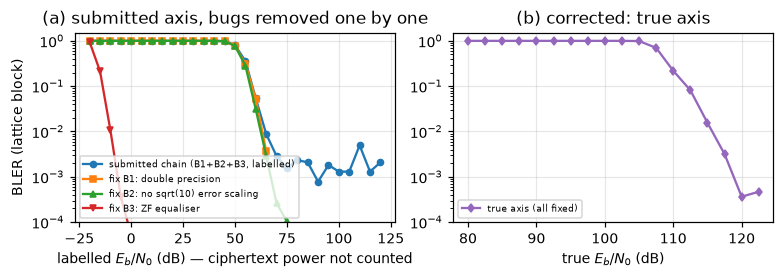

In [14]:
key = get_key(512, seed=7)
LAB_GRID = np.arange(-20.0, 120.1, 5.0)
steps = [("submitted chain (B1+B2+B3, labelled)", dict(chan_precision="single", sqrt10_bug=True, equalizer="lmmse", true_snr=False, complex_error=False)),
         ("fix B1: double precision",              dict(sqrt10_bug=True, equalizer="lmmse", true_snr=False)),
         ("fix B2: no sqrt(10) error scaling",     dict(equalizer="lmmse", true_snr=False)),
         ("fix B3: ZF equaliser",                  dict(equalizer="zf", true_snr=False))]
ABL = {}
for lab, kw in steps:
    ABL[lab] = simulate(GGHUplink("umi", key, **kw), LAB_GRID, label=lab[:34], stop_at_zero=False if "B1+" in lab else True,
                        max_iter=None if "B1+" not in lab else (4 if QUICK else 20))
ABL["true axis (all fixed)"] = simulate(GGHUplink("umi", key), GGH_GRID, label="true axis")
print("\nsubmitted-chain BLER at labelled 80 / 100 / 120 dB:",
      [f"{ABL[steps[0][0]]['bler'][list(LAB_GRID).index(v)]:.1e}" for v in [80.0, 100.0, 120.0]])
save_json(ABL, "ablation_submitted_chain")

fig, ax = plt.subplots(1, 2, figsize=(7.2, 2.6))
for i, (lab, r) in enumerate(ABL.items()):
    a_ = ax[1] if "true" in lab else ax[0]
    plot_curve(a_, r, marker="os^vd"[i], label=lab, color=f"C{i}")
ax[0].set_xlabel("labelled $E_b/N_0$ (dB) — ciphertext power not counted"); ax[0].set_ylabel("BLER (lattice block)")
ax[0].legend(fontsize=6); ax[0].set_ylim(1e-4, 1.5); ax[0].set_title("(a) submitted axis, bugs removed one by one")
ax[1].set_xlabel("true $E_b/N_0$ (dB)"); ax[1].set_ylim(1e-4, 1.5); ax[1].legend(fontsize=6)
ax[1].set_title("(b) corrected: true axis")
savefig(fig, "fig_ablation_submitted_chain")

## Part 5. Main result: GGH on the true SNR axis vs the unencrypted link

UMi, UMa, RMa; K = 4, M = 8, 16-QAM, uncoded, ZF, perfect CSI, full-band tile 128×4 (n = 512), **one fixed key** for all scenarios. The unencrypted link uses the same chain and the same 128×4 blocks for its block error rate. Eve receives exactly Bob's signal (worst case) and uses round-off with B.

In [15]:
key = get_key(512)
MAIN = {}
for sc in ["umi", "uma", "rma"]:
    MAIN[(sc, "ggh")] = simulate(GGHUplink(sc, key), GGH_GRID, label=f"{NAME[sc]} GGH Bob")
    MAIN[(sc, "plain")] = simulate(GGHUplink(sc, None), PLAIN_GRID, label=f"{NAME[sc]} unencrypted")
    MAIN[(sc, "eve")] = simulate(GGHUplink(sc, key, role="eve"), np.arange(0, 160.1, 20), label=f"{NAME[sc]} Eve",
                                 target_tile_err=50, stop_at_zero=False)
save_json({f"{a}_{b}": v for (a, b), v in MAIN.items()}, "main_true_axis")

  UMi GGH Bob                           80.0 dB | BER 4.991e-01 | BLER 1.000e+00 (384/384) |    0.2s


  UMi GGH Bob                           82.5 dB | BER 4.995e-01 | BLER 1.000e+00 (384/384) |    0.4s


  UMi GGH Bob                           85.0 dB | BER 4.993e-01 | BLER 1.000e+00 (384/384) |    0.6s


  UMi GGH Bob                           87.5 dB | BER 4.992e-01 | BLER 1.000e+00 (384/384) |    0.8s


  UMi GGH Bob                           90.0 dB | BER 4.861e-01 | BLER 1.000e+00 (384/384) |    1.0s


...

  RMa unencrypted                       27.5 dB | BER 1.094e-06 | BLER 3.125e-04 (6/19200) |   32.3s


  RMa unencrypted                       30.0 dB | BER 0.000e+00 | BLER 0.000e+00 (0/19200) |   38.3s
  RMa Eve                                0.0 dB | BER 4.999e-01 | BLER 1.000e+00 (192/192) |    0.1s


  RMa Eve                               20.0 dB | BER 4.979e-01 | BLER 1.000e+00 (192/192) |    0.2s
  RMa Eve                               40.0 dB | BER 4.994e-01 | BLER 1.000e+00 (192/192) |    0.3s
  RMa Eve                               60.0 dB | BER 4.993e-01 | BLER 1.000e+00 (192/192) |    0.4s


  RMa Eve                               80.0 dB | BER 4.984e-01 | BLER 1.000e+00 (192/192) |    0.5s
  RMa Eve                              100.0 dB | BER 4.966e-01 | BLER 1.000e+00 (192/192) |    0.6s
  RMa Eve                              120.0 dB | BER 4.858e-01 | BLER 1.000e+00 (192/192) |    0.7s


  RMa Eve                              140.0 dB | BER 4.865e-01 | BLER 1.000e+00 (192/192) |    0.8s
  RMa Eve                              160.0 dB | BER 4.852e-01 | BLER 1.000e+00 (192/192) |    0.9s


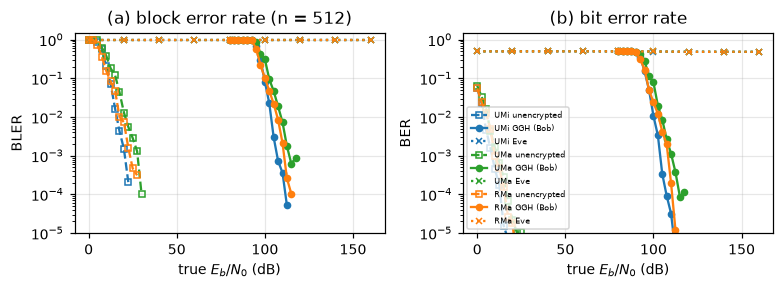

Eb/N0 for BLER = 0.01
 scenario  unencrypted     GGH  penalty  Eve BER @160dB
      UMi         15.9   103.5     87.6           0.485
      UMa         20.8   109.2     88.4           0.485
      RMa         17.6   107.1     89.4           0.485


In [16]:
fig, ax = plt.subplots(1, 2, figsize=(7.2, 2.7))
for sc in ["umi", "uma", "rma"]:
    for j, key_ in enumerate(["bler", "ber"]):
        plot_curve(ax[j], MAIN[(sc, "plain")], key_, color=COL[sc], ls="--", marker="s", mfc="none", label=f"{NAME[sc]} unencrypted")
        plot_curve(ax[j], MAIN[(sc, "ggh")], key_, color=COL[sc], ls="-", marker="o", label=f"{NAME[sc]} GGH (Bob)")
        plot_curve(ax[j], MAIN[(sc, "eve")], key_, color=COL[sc], ls=":", marker="x", label=f"{NAME[sc]} Eve")
for j, t in enumerate(["(a) block error rate (n = 512)", "(b) bit error rate"]):
    ax[j].set_xlabel("true $E_b/N_0$ (dB)"); ax[j].set_title(t); ax[j].set_ylim(1e-5, 1.5)
ax[0].set_ylabel("BLER"); ax[1].set_ylabel("BER"); ax[1].legend(fontsize=5.5, ncol=1, loc="lower left")
savefig(fig, "fig_main_true_axis")

main_tab = []
print(f"Eb/N0 for BLER = {TARGET_BLER:g}")
print(f"{'scenario':>9s}{'unencrypted':>13s}{'GGH':>8s}{'penalty':>9s}{'Eve BER @160dB':>16s}")
for sc in ["umi", "uma", "rma"]:
    p, g = snr_at(MAIN[(sc, "plain")]), snr_at(MAIN[(sc, "ggh")])
    main_tab.append(dict(scenario=NAME[sc], plain=p, ggh=g, penalty=g - p, eve_ber=MAIN[(sc, "eve")]["ber"][-1]))
    print(f"{NAME[sc]:>9s}{p:13.1f}{g:8.1f}{g-p:9.1f}{MAIN[(sc, 'eve')]['ber'][-1]:16.3f}")

## Part 6. Perfect vs imperfect CSI

Three CSI models (UMi, n = 512):
- **perfect**: the receiver knows H exactly (the submitted paper);
- **LS (Sionna)**: least-squares on the Kronecker pilots, with nearest-neighbour or linear interpolation across subcarriers (a practical estimator; its interpolation error does not shrink with SNR);
- **Gaussian, NMSE = N₀**: Ĥ = H + Δ, Δ ~ CN(0, N₀), an ideal noise-limited estimator (one unit-power pilot per RE, no interpolation error).

Then: BLER vs CSI NMSE at fixed high SNR, to find how accurate the CSI must be.

In [17]:
key = get_key(512)
CSI = {}
for csi in ["perfect", "gauss", "ls-lin", "ls-nn"]:
    grid = GGH_GRID if csi in ["perfect", "gauss"] else np.arange(80.0, 200.1, 20.0)
    CSI[(csi, "ggh")] = simulate(GGHUplink("umi", key, csi=csi), grid, label=f"GGH {csi}", stop_at_zero=csi in ["perfect", "gauss"])
    CSI[(csi, "plain")] = simulate(GGHUplink("umi", None, csi=csi), PLAIN_GRID, label=f"unencrypted {csi}",
                                   stop_at_zero=csi in ["perfect", "gauss"])

NMSE_GRID = np.arange(-160.0, -59.0, 10.0)
NM = {}
for e_ in [120.0, 140.0]:
    r = {"nmse_db": [], "bler": [], "ber": []}
    for nm in NMSE_GRID:
        o = simulate(GGHUplink("umi", key, csi="gauss", csi_nmse_db=float(nm)), [e_], label=f"NMSE {nm:.0f} dB @ {e_:.0f} dB",
                     target_tile_err=50, max_iter=10 if QUICK else 30)
        r["nmse_db"].append(float(nm)); r["bler"].append(o["bler"][0]); r["ber"].append(o["ber"][0])
    NM[e_] = r
save_json(dict(curves={f"{a}_{b}": v for (a, b), v in CSI.items()}, nmse={str(k): v for k, v in NM.items()}), "csi")

  GGH perfect                           80.0 dB | BER 4.994e-01 | BLER 1.000e+00 (384/384) |    0.2s


  GGH perfect                           82.5 dB | BER 5.006e-01 | BLER 1.000e+00 (384/384) |    0.4s


  GGH perfect                           85.0 dB | BER 4.984e-01 | BLER 1.000e+00 (384/384) |    0.6s
  GGH perfect                           87.5 dB | BER 4.981e-01 | BLER 1.000e+00 (384/384) |    0.8s


  GGH perfect                           90.0 dB | BER 4.874e-01 | BLER 1.000e+00 (384/384) |    1.0s


  GGH perfect                           92.5 dB | BER 3.808e-01 | BLER 9.896e-01 (380/384) |    1.2s


...

  NMSE -130 dB @ 140 dB                140.0 dB | BER 7.206e-06 | BLER 1.736e-04 (1/5760) |    3.4s


  NMSE -120 dB @ 140 dB                140.0 dB | BER 3.668e-03 | BLER 5.312e-02 (51/960) |    0.6s
  NMSE -110 dB @ 140 dB                140.0 dB | BER 1.698e-01 | BLER 9.219e-01 (177/192) |    0.1s


  NMSE -100 dB @ 140 dB                140.0 dB | BER 4.801e-01 | BLER 1.000e+00 (192/192) |    0.1s
  NMSE -90 dB @ 140 dB                 140.0 dB | BER 4.994e-01 | BLER 1.000e+00 (192/192) |    0.1s


  NMSE -80 dB @ 140 dB                 140.0 dB | BER 4.996e-01 | BLER 1.000e+00 (192/192) |    0.1s
  NMSE -70 dB @ 140 dB                 140.0 dB | BER 5.002e-01 | BLER 1.000e+00 (192/192) |    0.1s


  NMSE -60 dB @ 140 dB                 140.0 dB | BER 4.999e-01 | BLER 1.000e+00 (192/192) |    0.1s


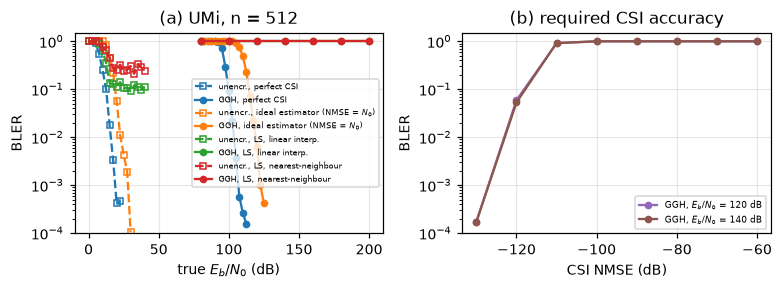

perfect CSI                        unencrypted   15.9 dB | GGH  103.6 dB | last-point BER: unencr. 0.0e+00, GGH 0.00
ideal estimator (NMSE = $N_0$)     unencrypted   22.8 dB | GGH  119.1 dB | last-point BER: unencr. 0.0e+00, GGH 0.00
LS, linear interp.                 unencrypted    nan dB | GGH    nan dB | last-point BER: unencr. 5.0e-04, GGH 0.50
LS, nearest-neighbour              unencrypted    nan dB | GGH    nan dB | last-point BER: unencr. 5.5e-03, GGH 0.50


In [18]:
fig, ax = plt.subplots(1, 2, figsize=(7.2, 2.7))
lab = {"perfect": "perfect CSI", "gauss": "ideal estimator (NMSE = $N_0$)", "ls-lin": "LS, linear interp.", "ls-nn": "LS, nearest-neighbour"}
for i, csi in enumerate(["perfect", "gauss", "ls-lin", "ls-nn"]):
    plot_curve(ax[0], CSI[(csi, "plain")], color=f"C{i}", ls="--", marker="s", mfc="none", label=f"unencr., {lab[csi]}")
    plot_curve(ax[0], CSI[(csi, "ggh")], color=f"C{i}", ls="-", marker="o", label=f"GGH, {lab[csi]}")
ax[0].set_xlabel("true $E_b/N_0$ (dB)"); ax[0].set_ylabel("BLER"); ax[0].set_ylim(1e-4, 1.5)
ax[0].legend(fontsize=5.5); ax[0].set_title("(a) UMi, n = 512")
for i, (e_, r) in enumerate(NM.items()):
    ax[1].semilogy(r["nmse_db"], np.where(np.array(r["bler"]) > 0, r["bler"], np.nan), "o-", color=f"C{i+4}",
                   label=f"GGH, $E_b/N_0$ = {e_:.0f} dB")
ax[1].set_xlabel("CSI NMSE (dB)"); ax[1].set_ylabel("BLER"); ax[1].set_ylim(1e-4, 1.5); ax[1].legend(fontsize=6)
ax[1].set_title("(b) required CSI accuracy")
savefig(fig, "fig_csi")

csi_tab = []
for csi in ["perfect", "gauss", "ls-lin", "ls-nn"]:
    p, g = snr_at(CSI[(csi, "plain")]), snr_at(CSI[(csi, "ggh")])
    csi_tab.append(dict(csi=lab[csi], plain=p, ggh=g, ggh_floor_ber=CSI[(csi, "ggh")]["ber"][-1],
                        plain_floor_ber=CSI[(csi, "plain")]["ber"][-1]))
    print(f"{lab[csi]:34s} unencrypted {p:6.1f} dB | GGH {g:6.1f} dB | last-point BER: unencr. {csi_tab[-1]['plain_floor_ber']:.1e}, GGH {csi_tab[-1]['ggh_floor_ber']:.2f}")

## Part 7. Receiver: ZF vs LMMSE (true axis)

On the true axis the transmit power is 1, so the LMMSE prior is correct again and both equalisers can be compared fairly (UMi, n = 512, perfect CSI).

  GGH zf                                80.0 dB | BER 5.001e-01 | BLER 1.000e+00 (384/384) |    0.2s


  GGH zf                                82.5 dB | BER 4.996e-01 | BLER 1.000e+00 (384/384) |    0.4s
  GGH zf                                85.0 dB | BER 4.985e-01 | BLER 1.000e+00 (384/384) |    0.6s


  GGH zf                                87.5 dB | BER 4.983e-01 | BLER 1.000e+00 (384/384) |    0.8s
  GGH zf                                90.0 dB | BER 4.887e-01 | BLER 1.000e+00 (384/384) |    1.0s


  GGH zf                                92.5 dB | BER 3.751e-01 | BLER 9.922e-01 (381/384) |    1.2s


  GGH zf                                95.0 dB | BER 1.866e-01 | BLER 7.630e-01 (293/384) |    1.4s


...

  unencrypted lmmse                     15.0 dB | BER 2.103e-05 | BLER 1.695e-02 (205/12096) |    9.0s


  unencrypted lmmse                     17.5 dB | BER 5.061e-06 | BLER 5.417e-03 (104/19200) |   18.4s


  unencrypted lmmse                     20.0 dB | BER 4.069e-07 | BLER 7.292e-04 (14/19200) |   27.8s


  unencrypted lmmse                     22.5 dB | BER 2.543e-08 | BLER 5.208e-05 (1/19200) |   37.2s


  unencrypted lmmse                     25.0 dB | BER 0.000e+00 | BLER 0.000e+00 (0/19200) |   46.6s


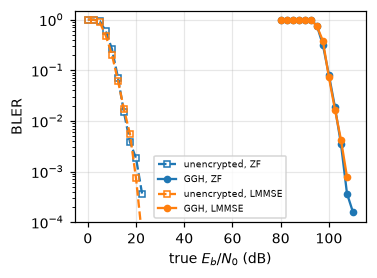

ZF    : unencrypted   15.7 dB, GGH  103.4 dB
LMMSE : unencrypted   16.2 dB, GGH  103.4 dB


In [19]:
key = get_key(512)
RX = {}
for eq in ["zf", "lmmse"]:
    RX[(eq, "ggh")] = simulate(GGHUplink("umi", key, equalizer=eq), GGH_GRID, label=f"GGH {eq}")
    RX[(eq, "plain")] = simulate(GGHUplink("umi", None, equalizer=eq), PLAIN_GRID, label=f"unencrypted {eq}")
save_json({f"{a}_{b}": v for (a, b), v in RX.items()}, "receiver")
fig, ax = plt.subplots(figsize=(3.5, 2.6))
for i, eq in enumerate(["zf", "lmmse"]):
    plot_curve(ax, RX[(eq, "plain")], color=f"C{i}", ls="--", marker="s", mfc="none", label=f"unencrypted, {eq.upper()}")
    plot_curve(ax, RX[(eq, "ggh")], color=f"C{i}", ls="-", marker="o", label=f"GGH, {eq.upper()}")
ax.set_xlabel("true $E_b/N_0$ (dB)"); ax.set_ylabel("BLER"); ax.set_ylim(1e-4, 1.5); ax.legend(fontsize=6)
savefig(fig, "fig_receiver")
for eq in ["zf", "lmmse"]:
    print(f"{eq.upper():6s}: unencrypted {snr_at(RX[(eq,'plain')]):6.1f} dB, GGH {snr_at(RX[(eq,'ggh')]):6.1f} dB")

## Part 8. Block size and error containment

Tiles (w subcarriers × T data symbols): full-band 128×4 (n = 512, submitted), full-band 128×3 (n = 384), sub-band 32×12 (n = 384), sub-band 16×12 (n = 192). Each n has its own key (shared by all users). Note that n < 350 is below the dimension usually asked for GGH (shown for comparison only).

For each failed block we count (i) wrong integers zᵢ after rounding, before U⁻¹, and (ii) wrong QAM symbols after U⁻¹. If (i) is small and (ii) is large, the damage comes from U⁻¹ spreading a local rounding error, not from R⁻¹ mixing the channel residuals.

  full-band 128×4 (n=512)               80.0 dB | BER 5.003e-01 | BLER 1.000e+00 (384/384) |    0.2s


  full-band 128×4 (n=512)               82.5 dB | BER 4.987e-01 | BLER 1.000e+00 (384/384) |    0.4s


  full-band 128×4 (n=512)               85.0 dB | BER 4.989e-01 | BLER 1.000e+00 (384/384) |    0.6s


  full-band 128×4 (n=512)               87.5 dB | BER 4.982e-01 | BLER 1.000e+00 (384/384) |    0.8s


  full-band 128×4 (n=512)               90.0 dB | BER 4.895e-01 | BLER 1.000e+00 (384/384) |    1.0s


...

  sub-band 16×12 (n=192)               105.0 dB | BER 1.061e-02 | BLER 4.536e-02 (209/4608) |    1.5s


  sub-band 16×12 (n=192)               107.5 dB | BER 1.798e-03 | BLER 8.619e-03 (203/23552) |    4.8s


  sub-band 16×12 (n=192)               110.0 dB | BER 2.720e-04 | BLER 1.602e-03 (82/51200) |   11.9s


  sub-band 16×12 (n=192)               112.5 dB | BER 8.715e-05 | BLER 3.906e-04 (20/51200) |   19.0s


  sub-band 16×12 (n=192)               115.0 dB | BER 0.000e+00 | BLER 0.000e+00 (0/51200) |   26.2s


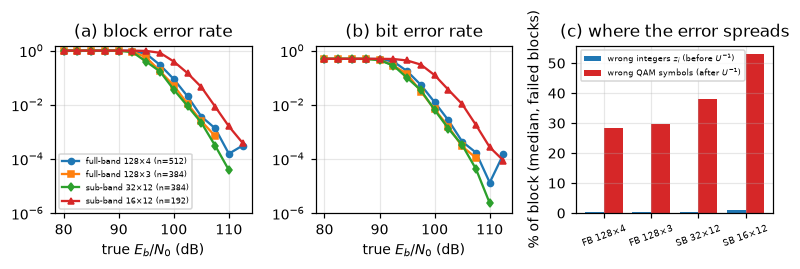

full-band 128×4 (n=512)    failed block: median 2 wrong integer(s) -> 28% wrong symbols | Eb/N0 @ BLER 0.01: 103.5 dB
full-band 128×3 (n=384)    failed block: median 1 wrong integer(s) -> 30% wrong symbols | Eb/N0 @ BLER 0.01: 102.6 dB
sub-band 32×12 (n=384)     failed block: median 2 wrong integer(s) -> 38% wrong symbols | Eb/N0 @ BLER 0.01: 102.3 dB
sub-band 16×12 (n=192)     failed block: median 2 wrong integer(s) -> 53% wrong symbols | Eb/N0 @ BLER 0.01: 107.3 dB


In [20]:
TILES = [("full-band 128×4 (n=512)", (128, 4)), ("full-band 128×3 (n=384)", (128, 3)),
         ("sub-band 32×12 (n=384)", (32, 12)), ("sub-band 16×12 (n=192)", (16, 12))]
TL = {}
for lab_, t in TILES:
    TL[lab_] = simulate(GGHUplink("umi", get_key(t[0] * t[1]), tile=t), GGH_GRID, label=lab_)
save_json(TL, "tiles")

fig, ax = plt.subplots(1, 3, figsize=(7.2, 2.4))
for i, (lab_, r) in enumerate(TL.items()):
    plot_curve(ax[0], r, "bler", marker="osd^"[i], label=lab_)
    plot_curve(ax[1], r, "ber", marker="osd^"[i], label=lab_)
for j, t in enumerate(["(a) block error rate", "(b) bit error rate"]):
    ax[j].set_xlabel("true $E_b/N_0$ (dB)"); ax[j].set_title(t); ax[j].set_ylim(1e-6, 1.5)
ax[0].legend(fontsize=5.5)
cont = []
for i, (lab_, r) in enumerate(TL.items()):
    n = int(lab_.split("n=")[1].rstrip(")"))
    zf = np.concatenate([np.array(v, float) for v in r["z_fail"] if len(v)]) if any(len(v) for v in r["z_fail"]) else np.array([np.nan])
    sf = np.concatenate([np.array(v, float) for v in r["sym_fail"] if len(v)]) if any(len(v) for v in r["sym_fail"]) else np.array([np.nan])
    # use only points near the waterfall (BLER < 0.5) so failures are "rare" ones
    zz, ss = [], []
    for zv, sv, b_ in zip(r["z_fail"], r["sym_fail"], r["bler"]):
        if 0 < b_ < 0.5: zz += zv; ss += sv
    zz, ss = (np.array(zz, float) if zz else zf), (np.array(ss, float) if ss else sf)
    cont.append(dict(tile=lab_, n=n, z_wrong_median=float(np.nanmedian(zz)), sym_wrong_frac_median=float(np.nanmedian(ss) / n)))
    ax[2].bar(i - 0.2, np.nanmedian(zz) / n * 100, 0.4, color="tab:blue", label="wrong integers $z_i$ (before $U^{-1}$)" if i == 0 else None)
    ax[2].bar(i + 0.2, np.nanmedian(ss) / n * 100, 0.4, color="tab:red", label="wrong QAM symbols (after $U^{-1}$)" if i == 0 else None)
ax[2].set_xticks(range(len(TL))); ax[2].set_xticklabels([l.split(" (")[0].replace("full-band ", "FB ").replace("sub-band ", "SB ") for l in TL], fontsize=6, rotation=20)
ax[2].set_ylabel("% of block (median, failed blocks)"); ax[2].legend(fontsize=5.5); ax[2].set_title("(c) where the error spreads")
savefig(fig, "fig_tiles_containment")
for c_ in cont:
    print(f"{c_['tile']:26s} failed block: median {c_['z_wrong_median']:.0f} wrong integer(s) -> {100*c_['sym_wrong_frac_median']:.0f}% wrong symbols"
          f" | Eb/N0 @ BLER {TARGET_BLER:g}: {snr_at(TL[c_['tile']]):.1f} dB")

## Part 9. Users, antennas and modulation

UMi, perfect CSI, ZF, full-band n = 512 tile, same key. (K, M) ∈ {(2, 8), (4, 8), (4, 16), (8, 16)} with 16-QAM, and QPSK / 16-QAM / 64-QAM with (K, M) = (4, 8). For each case we report the Eb/N0 at BLER = 10⁻² for GGH and for the unencrypted link, and the penalty.

  GGH K=2 M=8 16-QAM                    80.0 dB | BER 4.995e-01 | BLER 1.000e+00 (288/288) |    0.2s


  GGH K=2 M=8 16-QAM                    82.5 dB | BER 4.995e-01 | BLER 1.000e+00 (288/288) |    0.3s


  GGH K=2 M=8 16-QAM                    85.0 dB | BER 4.995e-01 | BLER 1.000e+00 (288/288) |    0.5s


  GGH K=2 M=8 16-QAM                    87.5 dB | BER 4.945e-01 | BLER 1.000e+00 (288/288) |    0.7s


  GGH K=2 M=8 16-QAM                    90.0 dB | BER 4.449e-01 | BLER 1.000e+00 (288/288) |    0.8s


...

  unencr. K=4 M=8 64-QAM                20.0 dB | BER 1.205e-05 | BLER 1.434e-02 (201/14016) |   15.5s


  unencr. K=4 M=8 64-QAM                22.5 dB | BER 1.136e-06 | BLER 2.396e-03 (46/19200) |   29.9s


  unencr. K=4 M=8 64-QAM                25.0 dB | BER 1.356e-07 | BLER 4.167e-04 (8/19200) |   43.6s


  unencr. K=4 M=8 64-QAM                27.5 dB | BER 5.086e-08 | BLER 1.563e-04 (3/19200) |   57.1s


  unencr. K=4 M=8 64-QAM                30.0 dB | BER 0.000e+00 | BLER 0.000e+00 (0/19200) |   72.2s


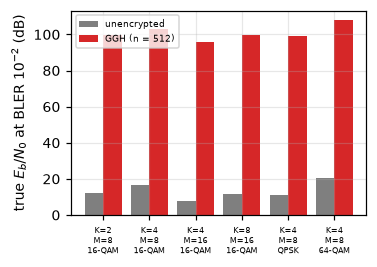

config                   unencrypted     GGH  penalty
K=2 M=8 16-QAM                  12.0    99.5     87.4
K=4 M=8 16-QAM                  16.4   103.3     86.9
K=4 M=16 16-QAM                  7.6    95.8     88.2
K=8 M=16 16-QAM                 11.6    99.7     88.1
K=4 M=8 QPSK                    11.2    99.3     88.2
K=4 M=8 64-QAM                  20.5   107.8     87.3


In [21]:
key = get_key(512)
CFG = [dict(K=2, M=8, bits=4), dict(K=4, M=8, bits=4), dict(K=4, M=16, bits=4), dict(K=8, M=16, bits=4),
       dict(K=4, M=8, bits=2), dict(K=4, M=8, bits=6)]
QAM = {2: "QPSK", 4: "16-QAM", 6: "64-QAM"}
SYS = []
for c_ in CFG:
    tag = f"K={c_['K']} M={c_['M']} {QAM[c_['bits']]}"
    rg_ = simulate(GGHUplink("umi", key, **c_), GGH_GRID, label="GGH " + tag)
    rp_ = simulate(GGHUplink("umi", None, **c_), np.arange(0.0, 60.1, 2.5), label="unencr. " + tag)
    SYS.append(dict(config=tag, **c_, plain=snr_at(rp_), ggh=snr_at(rg_), curves=dict(ggh=rg_, plain=rp_)))
for s_ in SYS: s_["penalty"] = s_["ggh"] - s_["plain"]
save_json(SYS, "system_configs")

fig, ax = plt.subplots(figsize=(3.5, 2.5))
xs = np.arange(len(SYS))
ax.bar(xs - 0.2, [s_["plain"] for s_ in SYS], 0.4, label="unencrypted", color="tab:gray")
ax.bar(xs + 0.2, [s_["ggh"] for s_ in SYS], 0.4, label="GGH (n = 512)", color="tab:red")
ax.set_xticks(xs); ax.set_xticklabels([s_["config"].replace(" ", "\n", 2) for s_ in SYS], fontsize=5.5)
ax.set_ylabel(f"true $E_b/N_0$ at BLER $10^{{-2}}$ (dB)"); ax.legend(fontsize=6)
savefig(fig, "fig_system_configs")
print(f"{'config':24s}{'unencrypted':>12s}{'GGH':>8s}{'penalty':>9s}")
for s_ in SYS: print(f"{s_['config']:24s}{s_['plain']:12.1f}{s_['ggh']:8.1f}{s_['penalty']:9.1f}")

## Part 10. Eavesdropper

1. **Q-branch leak.** The bases are real, so I and Q are encrypted separately. With a real-only error vector e = σ(±1), as written in the submitted Eq. (3), the Q part carries **no** error: Eve recovers it with round-off in B as soon as the noise is small. Per-bit BER for the 4 bits of each 16-QAM symbol (Sionna labelling: bits 0, 2 = I; bits 1, 3 = Q).
2. **Eve vs σ.** A smaller σ helps Bob (Part 3b). Does round-off with B still fail?

Eve here only runs Babai round-off with B, which is the weakest attack. GGH is broken by lattice reduction and embedding attacks (Nguyen 1999; Nguyen & Regev 2006), so these numbers show that the scheme is not trivially readable, not that it is secure.

  Eve sigma_frac=0.1                   160.0 dB | BER 3.852e-01 | BLER 1.000e+00 (192/192) |    0.1s


  Bob sigma_frac=0.1                    80.0 dB | BER 4.999e-01 | BLER 1.000e+00 (384/384) |    0.2s


  Bob sigma_frac=0.1                    82.5 dB | BER 4.998e-01 | BLER 1.000e+00 (384/384) |    0.4s


  Bob sigma_frac=0.1                    85.0 dB | BER 4.993e-01 | BLER 1.000e+00 (384/384) |    0.6s


  Bob sigma_frac=0.1                    87.5 dB | BER 4.988e-01 | BLER 1.000e+00 (384/384) |    0.8s


...

  Bob sigma_frac=0.9                   102.5 dB | BER 2.056e-03 | BLER 1.922e-02 (203/10560) |    9.0s


  Bob sigma_frac=0.9                   105.0 dB | BER 4.641e-04 | BLER 3.906e-03 (75/19200) |   20.1s


  Bob sigma_frac=0.9                   107.5 dB | BER 2.096e-04 | BLER 1.615e-03 (31/19200) |   33.4s


  Bob sigma_frac=0.9                   110.0 dB | BER 1.027e-05 | BLER 2.083e-04 (4/19200) |   43.8s


  Bob sigma_frac=0.9                   112.5 dB | BER 0.000e+00 | BLER 0.000e+00 (0/19200) |   53.7s


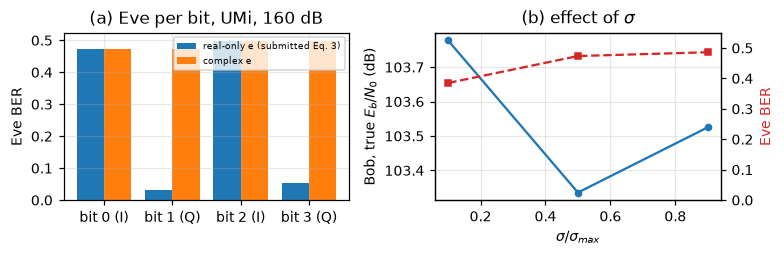

real-only e (submitted Eq. 3)  per-bit Eve BER = [0.473 0.031 0.499 0.053]
complex e                      per-bit Eve BER = [0.473 0.473 0.499 0.498]
sigma_frac=0.1: Bob needs 103.8 dB, Eve BER 0.385
sigma_frac=0.5: Bob needs 103.3 dB, Eve BER 0.474
sigma_frac=0.9: Bob needs 103.5 dB, Eve BER 0.486


In [22]:
key = get_key(512)
LEAK = {}
for ce in [False, True]:
    m_ = GGHUplink("umi", key, role="eve", complex_error=ce)
    acc = torch.zeros(4); bob = 0.0
    for _ in range(3 if QUICK else 10):
        with torch.no_grad():
            b, bh, _, _ = m_(16, 160.0)
        acc += (b != bh).double().reshape(-1, 4).mean(0).cpu()
    LEAK["complex e" if ce else "real-only e (submitted Eq. 3)"] = (acc / (3 if QUICK else 10)).tolist()
EVE_SIG = []
for sf in [0.1, 0.5, 0.9]:
    kk = get_key(512, sigma_frac=sf)
    r_e = simulate(GGHUplink("umi", kk, role="eve"), [160.0], label=f"Eve sigma_frac={sf}", target_tile_err=50, max_iter=5)
    r_b = simulate(GGHUplink("umi", kk), GGH_GRID, label=f"Bob sigma_frac={sf}")
    EVE_SIG.append(dict(sigma_frac=sf, eve_ber=r_e["ber"][0], bob_snr=snr_at(r_b)))
save_json(dict(leak=LEAK, eve_sigma=EVE_SIG), "eve")

fig, ax = plt.subplots(1, 2, figsize=(7.2, 2.4))
for i, (lab_, v) in enumerate(LEAK.items()):
    ax[0].bar(np.arange(4) + (i - 0.5) * 0.4, v, 0.4, label=lab_)
ax[0].set_xticks(range(4)); ax[0].set_xticklabels(["bit 0 (I)", "bit 1 (Q)", "bit 2 (I)", "bit 3 (Q)"])
ax[0].set_ylabel("Eve BER"); ax[0].legend(fontsize=6); ax[0].set_title("(a) Eve per bit, UMi, 160 dB")
ax[1].plot([r["sigma_frac"] for r in EVE_SIG], [r["bob_snr"] for r in EVE_SIG], "o-", label="Bob: $E_b/N_0$ at BLER $10^{-2}$")
ax2 = ax[1].twinx(); ax2.plot([r["sigma_frac"] for r in EVE_SIG], [r["eve_ber"] for r in EVE_SIG], "s--", color="tab:red", label="Eve BER")
ax2.set_ylim(0, 0.55); ax2.set_ylabel("Eve BER", color="tab:red"); ax2.grid(False)
ax[1].set_xlabel(r"$\sigma/\sigma_{max}$"); ax[1].set_ylabel("Bob, true $E_b/N_0$ (dB)"); ax[1].set_title(r"(b) effect of $\sigma$")
savefig(fig, "fig_eve")
for k_, v in LEAK.items(): print(f"{k_:30s} per-bit Eve BER = {np.round(v, 3)}")
for r in EVE_SIG: print(f"sigma_frac={r['sigma_frac']}: Bob needs {r['bob_snr']:.1f} dB, Eve BER {r['eve_ber']:.3f}")

## Part 11. Complexity, latency and goodput

- **Operations per block** (real multiply-adds, B and R real, m complex): encryption 2n², decryption 4n² (R⁻¹ then U⁻¹). Compared with the ZF equaliser per data RE.
- **Measured time** per block on this machine (batch of 1024 blocks).
- **Latency**: a block can only be decrypted after its T OFDM symbols have arrived (symbol duration with CP ≈ 35.7 µs at 30 kHz).
- **Goodput** = (1 − BLER) × uncoded rate, per user, from Part 5. (Same uncoded rate for GGH and the unencrypted link; GGH's cost is entirely the SNR.)

ZF equaliser: about 181 real MACs per user per RE (45 per bit, 16-QAM)
   n enc MAC/bit dec MAC/bit  enc µs/block  dec µs/block
 192          96         192          3.44          4.66
 384         192         384          8.03         12.26
 512         256         512          9.51         15.64
full-band 128×4 (n=512)    waits for  4 OFDM symbols =    154 µs before decryption
full-band 128×3 (n=384)    waits for  3 OFDM symbols =    116 µs before decryption
sub-band 32×12 (n=384)     waits for 12 OFDM symbols =    462 µs before decryption
sub-band 16×12 (n=192)     waits for 12 OFDM symbols =    462 µs before decryption


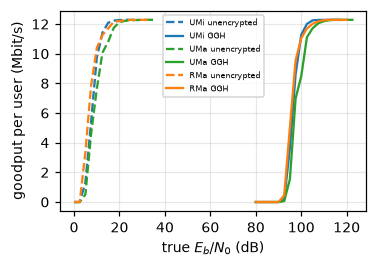

In [23]:
T_SYM = (128 + 20) / (128 * 30e3)                      # OFDM symbol incl. CP (s)
cx = []
for n in [192, 384, 512]:
    kk = get_key(n)
    m = (2.0 * torch.randint(0, 2, (1024, n), device=DEV) - 1) * (1 + 1j)
    t = time.perf_counter(); c = kk.encrypt(m); t_enc = (time.perf_counter() - t) / 1024
    t = time.perf_counter(); _ = kk.decrypt(c); t_dec = (time.perf_counter() - t) / 1024
    cx.append(dict(n=n, enc_ops=2 * n * n, dec_ops=4 * n * n, enc_ops_per_bit=2 * n * n / (4 * n), dec_ops_per_bit=4 * n * n / (4 * n),
                   enc_us=t_enc * 1e6, dec_us=t_dec * 1e6))
K_, M_ = 4, 8
zf_ops_per_re = (M_ * K_ * K_ + K_ ** 3 / 3 + M_ * K_) * 4 / K_    # per user per RE (rough, real MACs)
print(f"ZF equaliser: about {zf_ops_per_re:.0f} real MACs per user per RE ({zf_ops_per_re/4:.0f} per bit, 16-QAM)")
print(f"{'n':>4s}{'enc MAC/bit':>12s}{'dec MAC/bit':>12s}{'enc µs/block':>14s}{'dec µs/block':>14s}")
for c_ in cx:
    print(f"{c_['n']:4d}{c_['enc_ops_per_bit']:12.0f}{c_['dec_ops_per_bit']:12.0f}{c_['enc_us']:14.2f}{c_['dec_us']:14.2f}")
lat = [dict(tile=l, T=t[1], buffering_us=t[1] * T_SYM * 1e6) for l, t in TILES]
for l_ in lat: print(f"{l_['tile']:26s} waits for {l_['T']:2d} OFDM symbols = {l_['buffering_us']:6.0f} µs before decryption")

rate = 128 * 12 * 4 / 0.5e-3 / 1e6                    # Mbit/s per user (uncoded 16-QAM, 12 data symbols, 0.5 ms slot)
fig, ax = plt.subplots(figsize=(3.5, 2.5))
for sc in ["umi", "uma", "rma"]:
    for kind, ls in [("plain", "--"), ("ggh", "-")]:
        r = MAIN[(sc, kind)]
        x = list(r["ebno_db"]) + ([r["ebno_db"][-1] + 2.5] if r["bler"][-1] == 0 else [])
        y = [rate * (1 - b) for b in r["bler"]] + ([rate] if r["bler"][-1] == 0 else [])
        ax.plot(x, y, ls, color=COL[sc], label=f"{NAME[sc]} {'unencrypted' if kind == 'plain' else 'GGH'}")
ax.set_xlabel("true $E_b/N_0$ (dB)"); ax.set_ylabel("goodput per user (Mbit/s)"); ax.legend(fontsize=5.5)
savefig(fig, "fig_goodput")
save_json(dict(complexity=cx, latency=lat, zf_ops_per_re=zf_ops_per_re, rate_mbps=rate), "complexity")

## Part 12. Summary tables for the paper

In [24]:
def write_csv(rows, name):
    with open(f"{RES_DIR}/{name}.csv", "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)

write_csv(main_tab, "table_main_penalty")
write_csv([{k: v for k, v in s_.items() if k != "curves"} for s_ in SYS], "table_system_configs")
write_csv(csi_tab, "table_csi")
write_csv(awgn_rows, "table_awgn_required_snr")
write_csv(cont, "table_error_containment")

print("=== Key numbers ===")
for r in main_tab:
    print(f"{r['scenario']}: GGH needs {r['ggh']:.1f} dB vs {r['plain']:.1f} dB unencrypted -> penalty {r['penalty']:.1f} dB; Eve BER {r['eve_ber']:.2f}")
print(f"AWGN closed form (n=512): {awgn_rows[-1]['esno_closed']:.1f} dB = expansion {awgn_rows[-1]['expansion_db']:.1f} dB + lattice term {awgn_rows[-1]['lattice_term_db']:.1f} dB")
for r in csi_tab: print(f"CSI {r['csi']}: GGH {r['ggh']:.1f} dB (last-point BER {r['ggh_floor_ber']:.2f})")
print("Figures:", sorted(os.listdir(FIG_DIR)))

=== Key numbers ===
UMi: GGH needs 103.5 dB vs 15.9 dB unencrypted -> penalty 87.6 dB; Eve BER 0.49
UMa: GGH needs 109.2 dB vs 20.8 dB unencrypted -> penalty 88.4 dB; Eve BER 0.49
RMa: GGH needs 107.1 dB vs 17.6 dB unencrypted -> penalty 89.4 dB; Eve BER 0.49
AWGN closed form (n=512): 111.6 dB = expansion 113.8 dB + lattice term -2.3 dB
CSI perfect CSI: GGH 103.6 dB (last-point BER 0.00)
CSI ideal estimator (NMSE = $N_0$): GGH 119.1 dB (last-point BER 0.00)
CSI LS, linear interp.: GGH nan dB (last-point BER 0.50)
CSI LS, nearest-neighbour: GGH nan dB (last-point BER 0.50)
Figures: ['fig_ablation_submitted_chain.pdf', 'fig_ablation_submitted_chain.png', 'fig_awgn_theory_vs_sim.pdf', 'fig_awgn_theory_vs_sim.png', 'fig_csi.pdf', 'fig_csi.png', 'fig_eve.pdf', 'fig_eve.png', 'fig_goodput.pdf', 'fig_goodput.png', 'fig_key_distributions.pdf', 'fig_key_distributions.png', 'fig_main_true_axis.pdf', 'fig_main_true_axis.png', 'fig_mixing_Rinv_vs_Uinv.pdf', 'fig_mixing_Rinv_vs_Uinv.png', 'fig_rece

### How the results answer the reviews (fill in the numbers from the tables above)

- **Novelty (R1, R2, R3).** Closed-form required SNR (Part 2) splitting the cost into ciphertext expansion and lattice decoding; the security-vs-SNR map (Part 3); the corrected error mechanism (local rounding error, global spreading through U⁻¹; Parts 1 and 8); the required CSI accuracy (Part 6); the Q-branch leak of the real-only error vector (Part 10).
- **"Realistic" (R1).** Imperfect CSI (practical LS and an ideal estimator), several (K, M) and modulations, ZF and LMMSE, three scenarios with one fixed key.
- **Baselines (R1).** The unencrypted link on the same chain (Parts 5–9); complexity per bit compared with ZF (Part 11). Comparison with ML-KEM/FrodoKEM is left to the follow-up paper (mention in future work).
- **Trade-off (R1).** Part 3 and the penalty tables.
- **Throughput / latency (R3).** Part 11.
- **R2's question (why not PQC key agreement + symmetric encryption?).** The conclusion of this paper: an unbounded (non-modular) lattice ciphertext cannot be sent over the air at realistic SNR or with realistic CSI; a bounded (mod-q) ciphertext is needed, which motivates a KEM-based design (future work).
- **R3 small fixes.** Define c_k[n] in Eq. (4); capitalise "Physical"; describe the distributions of R and U (Part 1 text and figure); drop the image figure.